**Notebook Criado por:** MSc. Eng. Paulo Silva  
**Notebook Criado em:** 02 / 10 / 2026  
**Última Atualização:** 02 / 10 / 2026

Obs: Este notebook foi desenvolvido sob auxílio de ferramentas de IA.

# **Condução em regime transiente**

## **Aula 03 - Parte 3: formulação concentrada**

Neste notebook estudaremos o método da capacitância global, também chamado de formulação concentrada ou modelo lumped.

## **O que é condução transiente?**

Na condução em regime permanente, a temperatura não muda com o tempo. Já na condução transiente, a temperatura varia enquanto o corpo se aproxima da temperatura do meio ao seu redor. Um exemplo simples é um sólido inicialmente quente que é colocado em um fluido mais frio. O sólido perde energia por convecção e sua temperatura diminui ao longo do tempo.

O objetivo deste notebook é responder:

> Como estimar a temperatura do sólido em cada instante de tempo?

Para isso, vamos usar uma hipótese bastante simples: considerar que o corpo inteiro possui uma única temperatura em cada instante.

## **Situação física**

Considere um sólido que:

- começa com temperatura uniforme $T_0$;
- está em contato com um fluido à temperatura $T_\infty$;
- troca calor com o fluido por convecção;
- possui volume $V$, área superficial $A_s$, massa específica $\rho$ e calor específico $C$.

Vamos considerar inicialmente o caso de resfriamento, isto é, $T_0>T_\infty$. A mesma formulação também pode ser usada para aquecimento quando $T_0<T_\infty$.

O coeficiente de convecção será representado por $h$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

## **Hipótese da capacitância global**

A hipótese central do método é:

$$
T=T(t)
$$

Ou seja, a temperatura não depende da posição dentro do sólido. Em cada instante, imaginamos que o corpo inteiro está à mesma temperatura.

Essa hipótese é uma aproximação. Ela seria exata se a condução dentro do sólido fosse extremamente rápida, isto é, se a condutividade térmica $k$ fosse muito grande. Na prática, precisamos verificar se os gradientes internos de temperatura são pequenos o suficiente.

## **Balanço de energia**

A energia que sai do sólido por convecção é

$$
\dot{Q}_{conv}=hA_s(T-T_\infty).
$$

Como o sólido está resfriando, a sua energia interna diminui. A taxa de variação da energia armazenada é

$$
\rho VC\frac{dT}{dt}.
$$

Fazendo o balanço entre a energia que sai e a energia armazenada, obtemos

$$
-hA_s(T-T_\infty)=\rho VC\frac{dT}{dt}.
$$

Essa é a equação diferencial do modelo de capacitância global.

## **Temperatura em excesso**

Para deixar a equação mais simples, definimos a temperatura em excesso em relação ao fluido:

$$
\theta=T-T_\infty.
$$

No instante inicial,

$$
\theta_0=T_0-T_\infty.
$$

Como $T_\infty$ é constante, temos

$$
\frac{d\theta}{dt}=\frac{dT}{dt}.
$$

Substituindo essa definição no balanço de energia:

$$
-hA_s\theta=\rho VC\frac{d\theta}{dt}.
$$

Separando as variáveis:

$$
-dt=\frac{\rho VC}{hA_s}\frac{d\theta}{\theta}.
$$

## **Integração da equação**

Integramos desde o instante inicial até um instante qualquer $t$:

$$
\frac{\rho VC}{hA_s}
\int_{\theta_0}^{\theta}\frac{d\theta}{\theta}
=-\int_0^t dt.
$$

Como a integral de $1/\theta$ é um logaritmo:

$$
\frac{\rho VC}{hA_s}
\ln\left(\frac{\theta}{\theta_0}\right)=-t.
$$

Isolando a razão entre as temperaturas em excesso, chegamos à solução da formulação concentrada.

## **Solução da capacitância global**

A resposta do sólido é

$$
\frac{\theta}{\theta_0}
=\frac{T-T_\infty}{T_0-T_\infty}
=\exp\left(-\frac{hA_s}{\rho VC}t\right).
$$

Essa expressão mostra que a temperatura varia de forma exponencial. No início, a variação é mais rápida; com o passar do tempo, a temperatura se aproxima cada vez mais de $T_\infty$.

## **Constante de tempo**

Definimos a constante de tempo térmica:

$$
\tau_t=\frac{\rho VC}{hA_s}.
$$

Assim, a solução pode ser escrita como

$$
\frac{\theta}{\theta_0}=\exp\left(-\frac{t}{\tau_t}\right).
$$

A constante $\tau_t$ indica a velocidade da resposta:

- quanto maior for $\tau_t$, mais lento será o aquecimento ou resfriamento;
- quanto menor for $\tau_t$, mais rapidamente o sólido se aproxima de $T_\infty$;
- quando $t=\tau_t$, a razão $\theta/\theta_0$ vale $1/e$, aproximadamente $0{,}368$.

Também podemos interpretar $\tau_t$ como o produto entre uma resistência térmica convectiva e uma capacidade térmica:

$$
\tau_t=R_tC_t,
\qquad
R_t=\frac{1}{hA_s},
\qquad
C_t=\rho VC.
$$

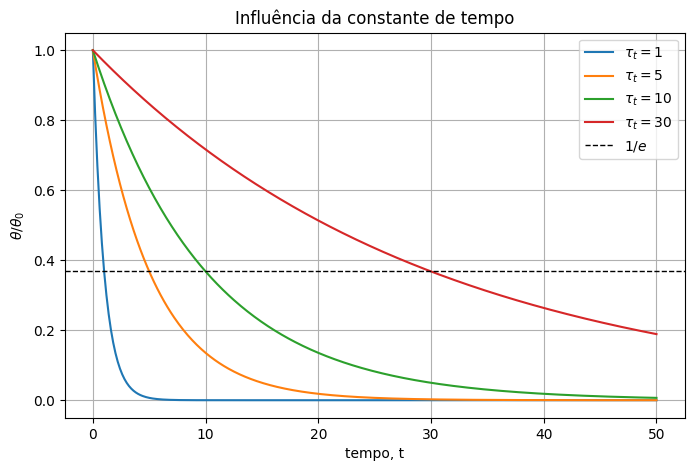

In [2]:
# A constante de tempo controla a rapidez da resposta exponencial.
t = np.linspace(0, 50, 500)
tau_values = [1, 5, 10, 30]

plt.figure(figsize=(8, 5))
for tau in tau_values:
    plt.plot(t, np.exp(-t / tau), label=fr"$\tau_t={tau}$")

plt.axhline(1 / np.e, color="black", linestyle="--", linewidth=1,
            label=r"$1/e$")
plt.xlabel("tempo, t")
plt.ylabel(r"$\theta/\theta_0$")
plt.title("Influência da constante de tempo")
plt.grid(True)
plt.legend()
plt.show()

## **Quando a hipótese é adequada? O número de Biot**

O número de Biot compara a dificuldade de conduzir calor dentro do sólido com a dificuldade de transferir calor entre a superfície e o fluido:

$$
Bi=\frac{R_{cond}}{R_{conv}}.
$$

Para uma parede plana, podemos escrever

$$
Bi=\frac{hL}{k}.
$$

De forma mais geral:

$$
Bi=\frac{hL_c}{k},
\qquad
L_c=\frac{V}{A_s}.
$$

A interpretação prática é:

- $Bi<0{,}1$: os gradientes internos tendem a ser pequenos e a capacitância global costuma ser adequada;
- $Bi$ próximo de $0{,}1$: estamos próximos do limite usual de validade;
- $Bi$ maior que $0{,}1$: a temperatura pode variar bastante dentro do sólido e a hipótese de temperatura uniforme deve ser usada com cuidado.

Portanto, o número de Biot deve ser calculado antes de aplicar a solução exponencial.

## **Número de Fourier**

Outro número adimensional importante é o número de Fourier:

$$
Fo=\frac{\alpha t}{L_c^2},
\qquad
\alpha=\frac{k}{\rho C}.
$$

Ele relaciona o tempo decorrido com o tempo necessário para a condução térmica atravessar uma distância característica.

Como

$$
\tau_t=\frac{\rho C L_c}{h},
$$

podemos mostrar que

$$
\frac{t}{\tau_t}=Bi\,Fo.
$$

Assim, a solução da capacitância global também pode ser escrita como

$$
\frac{\theta}{\theta_0}=\exp(-Bi\,Fo).
$$

Neste notebook, essa forma será usada apenas para visualizar como $Bi$ influencia a resposta da própria formulação concentrada.

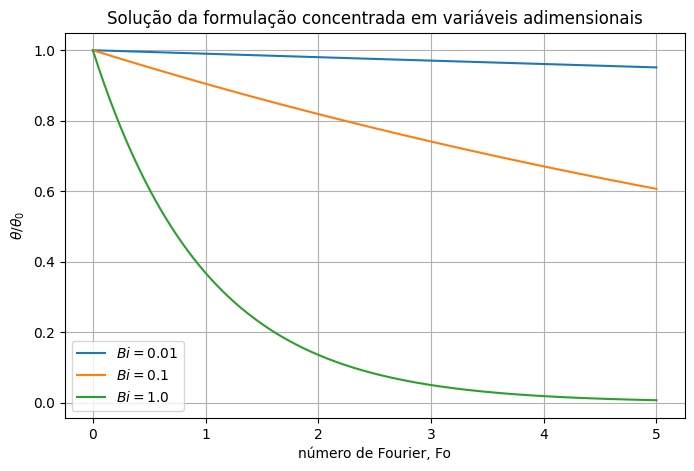

In [3]:
# Forma adimensional da solução da capacitância global.
Fo = np.linspace(0, 5, 500)
Bi_values = [0.01, 0.1, 1.0]

plt.figure(figsize=(8, 5))
for Bi in Bi_values:
    plt.plot(Fo, np.exp(-Bi * Fo), label=fr"$Bi={Bi}$")

plt.xlabel("número de Fourier, Fo")
plt.ylabel(r"$\theta/\theta_0$")
plt.title("Solução da formulação concentrada em variáveis adimensionais")
plt.grid(True)
plt.legend()
plt.show()

## **Exemplo: termopar esférico**

Deseja-se projetar um termopar esférico de bronze para que sua constante de tempo seja

$$
\tau_t=1\ \text{s}.
$$

O termopar será colocado em um gás quente. Os dados são:

| grandeza | valor |
|---|---:|
| coeficiente de convecção, $h$ | $400\ \text{W/(m² K)}$ |
| condutividade térmica, $k$ | $20\ \text{W/(m K)}$ |
| calor específico, $C$ | $400\ \text{J/(kg K)}$ |
| massa específica, $\rho$ | $8500\ \text{kg/m³}$ |
| temperatura inicial, $T_0$ | $25^\circ\text{C}$ |
| temperatura do gás, $T_\infty$ | $200^\circ\text{C}$ |

Queremos determinar o tamanho da esfera e o tempo necessário para ela atingir

$$
T_f=199^\circ\text{C}.
$$

## **Geometria da esfera**

Para uma esfera de raio $R$:

$$
V=\frac{4}{3}\pi R^3,
\qquad
A_s=4\pi R^2.
$$

Logo, o comprimento característico é

$$
L_c=\frac{V}{A_s}=\frac{R}{3}.
$$

Usando $\tau_t=\rho C L_c/h$, calculamos primeiro $L_c$. Depois obtemos o raio e o diâmetro:

$$
R=3L_c,
\qquad
D=2R.
$$

In [4]:
# Dados do exemplo do termopar
h = 400.0       # W/(m² K)
k = 20.0        # W/(m K)
C = 400.0       # J/(kg K)
rho = 8500.0    # kg/m³

tau_alvo = 1.0  # s
T0 = 25.0       # °C
Tinf = 200.0    # °C
Tf = 199.0      # °C

# Da expressão tau_t = rho*C*Lc/h:
Lc = tau_alvo * h / (rho * C)
R = 3 * Lc
D = 2 * R

# Verificação da hipótese de capacitância global:
Bi = h * Lc / k

print(f"Comprimento característico Lc = {Lc:.2e} m")
print(f"Raio da esfera R = {R:.2e} m")
print(f"Diâmetro da esfera D = {D:.2e} m = {D*1000:.3f} mm")
print(f"Número de Biot Bi = {Bi:.2e}")

if Bi < 0.1:
    print("Conclusão: Bi < 0,1; a formulação concentrada é adequada.")
else:
    print("Conclusão: Bi >= 0,1; a hipótese deve ser avaliada com cuidado.")

Comprimento característico Lc = 1.18e-04 m
Raio da esfera R = 3.53e-04 m
Diâmetro da esfera D = 7.06e-04 m = 0.706 mm
Número de Biot Bi = 2.35e-03
Conclusão: Bi < 0,1; a formulação concentrada é adequada.


## **Tempo para atingir a temperatura desejada**

Partimos da solução

$$
\frac{T-T_\infty}{T_0-T_\infty}
=\exp\left(-\frac{t}{\tau_t}\right).
$$

Para determinar o instante em que o termopar atinge $T_f$, substituímos $T$ por $T_f$:

$$
\frac{T_f-T_\infty}{T_0-T_\infty}
=\exp\left(-\frac{t_f}{\tau_t}\right).
$$

Isolando o tempo:

$$
t_f=-\tau_t\ln\left(
\frac{T_f-T_\infty}{T_0-T_\infty}
\right).
$$

Razão final theta_f/theta_0 = 0.005714
Tempo para atingir Tf = 5.1648 s


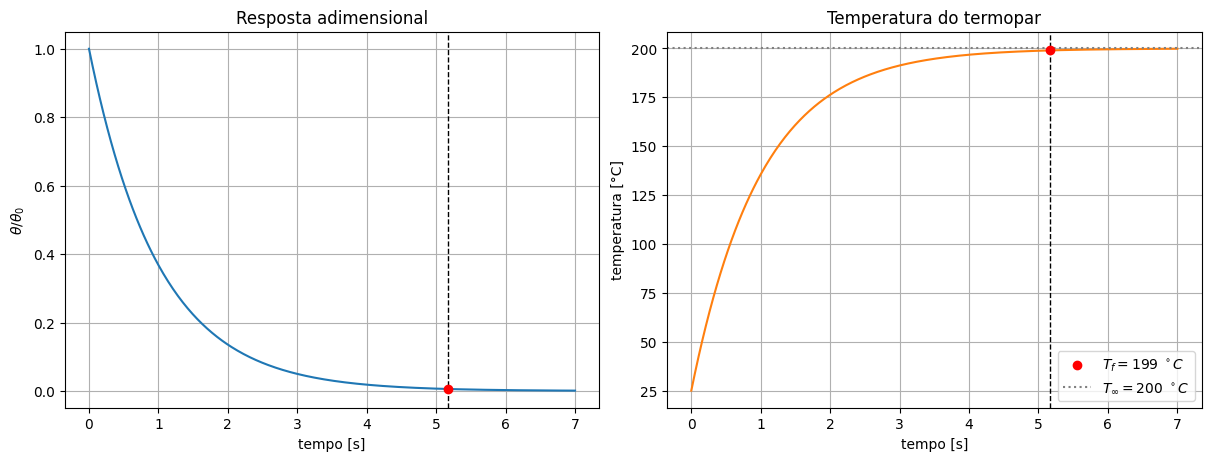

In [5]:
# Cálculo do tempo e visualização da resposta do termopar
razao_final = (Tf - Tinf) / (T0 - Tinf)
t_final = -tau_alvo * np.log(razao_final)

print(f"Razão final theta_f/theta_0 = {razao_final:.6f}")
print(f"Tempo para atingir Tf = {t_final:.4f} s")

tempo = np.linspace(0, 7, 400)
razao = np.exp(-tempo / tau_alvo)
temperatura = Tinf + (T0 - Tinf) * razao

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(tempo, razao, color="tab:blue")
axes[0].axvline(t_final, color="black", linestyle="--", linewidth=1)
axes[0].scatter([t_final], [razao_final], color="red", zorder=3)
axes[0].set_xlabel("tempo [s]")
axes[0].set_ylabel(r"$\theta/\theta_0$")
axes[0].set_title("Resposta adimensional")
axes[0].grid(True)

axes[1].plot(tempo, temperatura, color="tab:orange")
axes[1].axvline(t_final, color="black", linestyle="--", linewidth=1)
axes[1].scatter([t_final], [Tf], color="red", zorder=3,
                label=fr"$T_f={Tf:.0f}\ ^\circ C$")
axes[1].axhline(Tinf, color="gray", linestyle=":", label=fr"$T_\infty={Tinf:.0f}\ ^\circ C$")
axes[1].set_xlabel("tempo [s]")
axes[1].set_ylabel("temperatura [°C]")
axes[1].set_title("Temperatura do termopar")
axes[1].grid(True)
axes[1].legend()

plt.show()

## **Exemplo: Influência do número de Biot - bloco cúbico**

Para visualizar a influência do número de Biot, vamos considerar um bloco cúbico inicialmente a uma temperatura uniforme $T_0$, imerso em um fluido à temperatura $T_\infty$.

<div align="center">
    <img src="https://raw.githubusercontent.com/Paulo-de-Souza/HeatTransferPINN/main/Images/aula3/fig_03_exemplo-1.png"
    width="800">
</div>

Para manter o problema simples, assumiremos que:

- o calor atravessa o bloco apenas na direção $x$;
- as faces laterais são isoladas;
- as duas faces opostas trocam calor por convecção;
- as propriedades térmicas são constantes.

Devido à simetria, podemos analisar apenas metade do bloco:

$$ 0 \leq x \leq L. $$

No centro do bloco, em $x=0$, não há fluxo de calor. Na superfície, em $x=L$, ocorre convecção com o fluido.

O problema é:

$$
\frac{\partial T}{\partial t} = \alpha\frac{\partial^2 T}{\partial x^2},
$$

com

$$
\left.\frac{\partial T}{\partial x}\right|_{x=0}=0
\qquad \text{e} \qquad
-k\left.\frac{\partial T}{\partial x}\right|_{x=L} = h[T(L,t)-T_\infty].
$$

---

### **Discretização da malha**

Dividimos o domínio em $N$ pontos igualmente espaçados:

$$x_i=i\Delta x, \qquad \Delta x=\frac{L}{N-1},$$

com

$$i=0,1,2,\ldots,N-1.$$

Também podemos dividir o tempo em instantes:

$$t^n=n\Delta t.$$

A temperatura no ponto $x_i$ e no instante $t^n$ será representada por

$$T_i^n \approx T(x_i,t^n).$$

---

### **Diferenças finitas para os pontos internos**

Para os pontos internos, a derivada segunda em relação a $x$ é aproximada pela diferença centrada:

$$
\frac{\partial^2 T}{\partial x^2}
\approx
\frac{T_{i+1}^n-2T_i^n+T_{i-1}^n}{\Delta x^2}.
$$

Substituindo essa aproximação na equação do calor:

$$
\frac{dT_i}{dt}
=
\alpha
\frac{T_{i+1}-2T_i+T_{i-1}}
{\Delta x^2}.
$$

Caso o tempo também seja discretizado pelo método de Euler explícito:

$$
\frac{T_i^{n+1}-T_i^n}{\Delta t} = \alpha \frac{T_{i+1}^n-2T_i^n+T_{i-1}^n} {\Delta x^2}.
$$

Portanto:

$$
T_i^{n+1} = T_i^n + Fo \left(T_{i+1}^n-2T_i^n+T_{i-1}^n \right),
$$

onde

$$
Fo=\frac{\alpha\Delta t}{\Delta x^2}
$$

é o número de Fourier da malha.

---

### **Condição de simetria no centro**

No centro do bloco, temos:

$$
\left.\frac{\partial T}{\partial x}\right|_{x=0}=0.
$$

Para representar essa condição, utilizamos um ponto fantasma à esquerda do domínio. A diferença centrada da primeira derivada é:

$$
\frac{T_1-T_{-1}}{2\Delta x}=0.
$$

Logo:

$$
T_{-1}=T_1.
$$

Assim, a derivada segunda no centro pode ser escrita como:

$$
\left.\frac{\partial^2T}{\partial x^2}\right|_{x=0}
\approx \frac{T_1-2T_0+T_{-1}}{\Delta x^2} = \frac{2(T_1-T_0)}{\Delta x^2}.
$$

Portanto, no centro:

$$\frac{dT_0}{dt} = \alpha \frac{2(T_1-T_0)}{\Delta x^2}.$$

---

### **Condição convectiva na superfície**

Na superfície $x=L$, temos:

$$-k\frac{\partial T}{\partial x} = h(T-T_\infty).$$

Usando uma diferença centrada com um ponto fantasma externo $T_N$:

$$-k \frac{T_N-T_{N-2}}{2\Delta x} = h(T_{N-1}-T_\infty).$$

Isolando a temperatura do ponto fantasma:

$$T_N = T_{N-2} - \frac{2h\Delta x}{k} (T_{N-1}-T_\infty).$$

A derivada segunda na superfície pode então ser aproximada por:

$$ \left.\frac{\partial^2T}{\partial x^2}\right|_{x=L}
\approx \frac{T_N-2T_{N-1}+T_{N-2}}{\Delta x^2}. $$

Consequentemente:

$$ \frac{dT_{N-1}}{dt} = \alpha \frac{T_N-2T_{N-1}+T_{N-2}}{\Delta x^2}.$$

Dessa forma, as condições de contorno também são incorporadas ao sistema de diferenças finitas.

---

### **Sistema utilizado no código**

Após a discretização espacial, a equação diferencial parcial transforma-se em um sistema de equações diferenciais ordinárias:

$$ \frac{d\mathbf{T}}{dt} = \mathbf{F}(\mathbf{T}),$$

em que

$$\mathbf{T} = [T_0,T_1,\ldots,T_{N-1}]^T.$$

No código, esse sistema é integrado no tempo utilizando um método numérico. Assim, as diferenças finitas são utilizadas para aproximar as derivadas espaciais, enquanto o integrador temporal calcula a evolução das temperaturas.

A solução obtida por essa discretização será utilizada como uma solução de referência para comparação com a solução da capacitância global.

## **Codigo - Solucao de referencia por diferenças finitas**

In [6]:
# Geometria e condições térmicas
L = 0.01       # metade da espessura do bloco [m]
h = 300.0      # coeficiente de convecção [W/(m² K)]
T0 = 400.0     # temperatura inicial [°C]
Tinf = 300.0   # temperatura do fluido [°C]

# Número de pontos da malha espacial
N = 51

# Número de Fourier escolhido para a integração explícita
Fo_escolhido = 0.2

def bloco_diferencas_finitas(k, rho, cp, tempo_final, n_tempos=601, ):
    """
    Resolve a condução transiente 1D em metade de um bloco plano.

    As derivadas espaciais e temporais são aproximadas
    por diferenças finitas explícitas.
    """

    # Malha espacial
    x = np.linspace(0.0, L, N)
    dx = x[1] - x[0]

    # Difusividade térmica
    alpha = k / (rho * cp)

    # Passo de tempo máximo associado ao número de Fourier escolhido
    dt_max = Fo_escolhido * dx**2 / alpha

    # Número de passos necessário para atingir o tempo final
    n_passos = int(np.ceil(tempo_final / dt_max))

    # Ajuste para que o tempo final seja atingido exatamente
    dt = tempo_final / n_passos

    # Índices dos instantes que serão armazenados
    indices_saida = np.linspace(0, n_passos,  n_tempos,).round().astype(int)

    tempos = indices_saida * dt

    # Temperatura inicial
    T = np.full(N, T0)

    # Histórico da temperatura
    temperaturas = np.zeros((N, n_tempos))
    temperaturas[:, 0] = T

    proxima_saida = 1

    # Integração explícita no tempo
    for passo in range(1, n_passos + 1):
        dTdt = np.zeros_like(T)

        # Centro do bloco: condição de simetria, dT/dx = 0
        dTdt[0] = (alpha * 2.0 * (T[1] - T[0]) / dx**2)

        # Pontos internos: diferença centrada para a derivada segunda
        dTdt[1:-1] = alpha * (T[2:] - 2.0 * T[1:-1] + T[:-2]) / dx**2

        # Superfície:
        # condição convectiva
        #
        # -k*dT/dx = h*(T - Tinf)
        #
        # Utilização de um ponto fantasma
        Tfantasma = (T[-2] - 2.0 * dx * h / k * (T[-1] - Tinf))

        dTdt[-1] = alpha * (Tfantasma - 2.0 * T[-1] + T[-2]) / dx**2

        # Atualização explícita de Euler
        T = T + dt * dTdt

        # Armazenamento dos resultados nos tempos desejados
        while (proxima_saida < n_tempos and passo >= indices_saida[proxima_saida]):
            temperaturas[:, proxima_saida] = T
            proxima_saida += 1

    # Número de Fourier efetivamente utilizado
    Fo_real = alpha * dt / dx**2

    print(f"dx = {dx:.3e} m")
    print(f"dt = {dt:.3e} s")
    print(f"Fo utilizado = {Fo_real:.4f}")

    return tempos, x, temperaturas

## **Dois materiais, dois números de Biot**

Agora vamos manter a mesma geometria e o mesmo coeficiente de convecção, alterando apenas o material do bloco.

Para uma parede plana de espessura total $2L$, o comprimento característico é

$$
L_c=\frac{V}{A_s}=L.
$$

Portanto,

$$
Bi=\frac{hL}{k}.
$$

Serão analisados dois casos:

1. um bloco de aço, com maior condutividade térmica;
2. um bloco isolante, com baixa condutividade térmica.

O primeiro caso deverá apresentar $Bi < 0,1$, enquanto o segundo terá um número de Biot próximo de $10$.

A solução obtida pelas diferenças finitas será utilizada como uma solução de referência numérica. Ela não é uma solução analítica exata, mas uma aproximação bastante refinada da solução do problema espacialmente distribuído.

---

> Como a solução de diferenças finitas fornece uma temperatura para cada posição \(x\), calculamos a média da temperatura por:
$$
\overline{\theta}(t) = \frac{1}{L} \int_0^L \theta(x,t)\,dx.
$$

In [7]:
casos = {
    "Bi baixo - aço": {
        "k": 45.0,
        "rho": 7800.0,
        "cp": 500.0,
    },
    "Bi alto - isolante": {
        "k": 0.3,
        "rho": 1200.0,
        "cp": 1800.0,
    },
}

Lc = L
resultados = {}

for nome, propriedades in casos.items():
    k = propriedades["k"]
    rho = propriedades["rho"]
    cp = propriedades["cp"]

    Bi = h * Lc / k
    tau = rho * cp * Lc / h

    # 6 * tau representa 99.75% da solucao lumped
    tempo, x, temperatura = bloco_diferencas_finitas(
        k=k,
        rho=rho,
        cp=cp,
        tempo_final=15.0 * tau,
    )

    theta = (temperatura - Tinf) / (T0 - Tinf)

    # Temperatura média do bloco
    integrar = getattr(np, "trapezoid", np.trapz)
    theta_media = (integrar(theta, x, axis=0) / L)

    # Solução da capacitância global
    theta_lumped = np.exp(-tempo / tau)

    erro_absoluto = np.abs(theta_media - theta_lumped)

    resultados[nome] = {
        "Bi": Bi,
        "tau": tau,
        "tempo": tempo,
        "x": x,
        "theta": theta,
        "theta_media": theta_media,
        "theta_lumped": theta_lumped,
        "erro": erro_absoluto,
    }

    indice_tau = np.argmin(
        np.abs(tempo / tau - 1.0)
    )

    print(f"\n{nome}")
    print(f"Bi = {Bi:.4f}")
    print(f"tau = {tau:.2f} s")
    print(
        "theta médio em t/tau = 1: "
        f"{theta_media[indice_tau]:.4f}"
    )
    print(
        "theta lumped em t/tau = 1: "
        f"{theta_lumped[indice_tau]:.4f}"
    )
    print(
        f"Erro máximo absoluto: "
        f"{np.max(erro_absoluto):.4f}\n"
    )

dx = 2.000e-04 m
dt = 6.933e-04 s
Fo utilizado = 0.2000

Bi baixo - aço
Bi = 0.0667
tau = 130.00 s
theta médio em t/tau = 1: 0.3760
theta lumped em t/tau = 1: 0.3679
Erro máximo absoluto: 0.0081

dx = 2.000e-04 m
dt = 5.760e-02 s
Fo utilizado = 0.2000

Bi alto - isolante
Bi = 10.0000
tau = 72.00 s
theta médio em t/tau = 1: 0.7260
theta lumped em t/tau = 1: 0.3679
Erro máximo absoluto: 0.4487



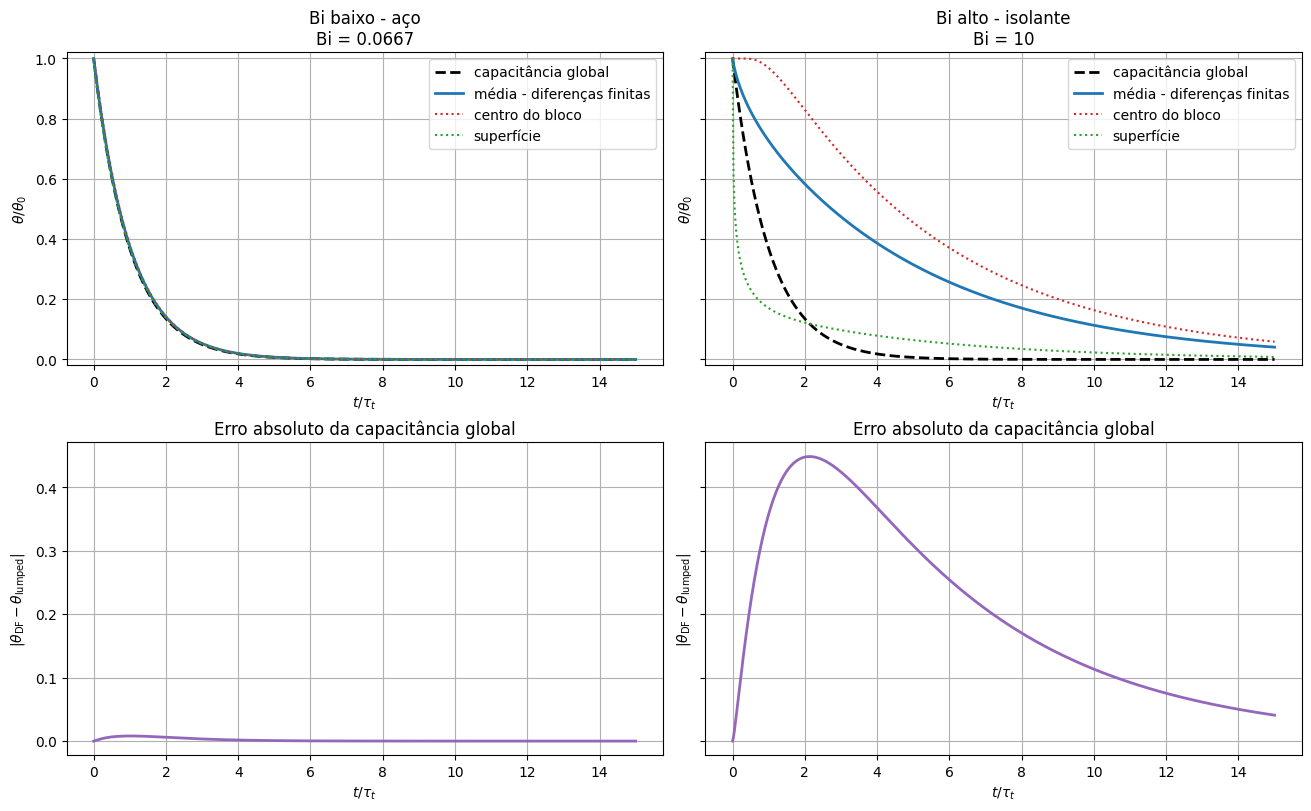

In [15]:
# Utilizar sharey="row" para partilhar a escala vertical apenas entre gráficos da mesma linha
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey="row", constrained_layout=True)

for coluna, (nome, resultado) in enumerate(resultados.items()):
    Bi = resultado["Bi"]
    tau = resultado["tau"]
    tempo_normalizado = resultado["tempo"] / tau

    theta_lumped = resultado["theta_lumped"]
    theta_media = resultado["theta_media"]
    theta_centro = resultado["theta"][0, :]
    theta_superficie = resultado["theta"][-1, :]
    erro = resultado["erro"]

    # --- Gráficos da Linha 0 (Temperaturas) ---
    axes[0, coluna].plot(tempo_normalizado, theta_lumped, "k--", linewidth=2, label="capacitância global")
    axes[0, coluna].plot(tempo_normalizado, theta_media, color="tab:blue", linewidth=2, label="média - diferenças finitas")
    axes[0, coluna].plot(tempo_normalizado, theta_centro, ":", color="tab:red", label="centro do bloco")
    axes[0, coluna].plot(tempo_normalizado, theta_superficie, ":", color="tab:green", label="superfície")

    axes[0, coluna].set_title(f"{nome}\nBi = {Bi:.3g}")
    axes[0, coluna].set_xlabel(r"$t/\tau_t$")
    axes[0, coluna].set_ylabel(r"$\theta/\theta_0$")
    axes[0, coluna].set_ylim(-0.02, 1.02)
    axes[0, coluna].grid(True)
    axes[0, coluna].legend(fontsize=10)

    # --- Gráficos da Linha 1 (Erro) ---
    axes[1, coluna].plot(
        tempo_normalizado,
        erro,
        color="tab:purple",
        linewidth=2,
    )

    axes[1, coluna].set_title("Erro absoluto da capacitância global")
    axes[1, coluna].set_xlabel(r"$t/\tau_t$")
    axes[1, coluna].set_ylabel(r"$|\theta_{\mathrm{DF}}-\theta_{\mathrm{lumped}}|$")
    axes[1, coluna].grid(True)

    # IMPORTANTE: Removida a linha axes[1, coluna].set_yscale("log")

    # Opcional: Se o sharey="row" não alinhar como o professor pretende,
    # pode forçar manualmente o mesmo limite para ambos os gráficos de erro:
    # axes[1, coluna].set_ylim(-0.01, 0.5)

plt.show()

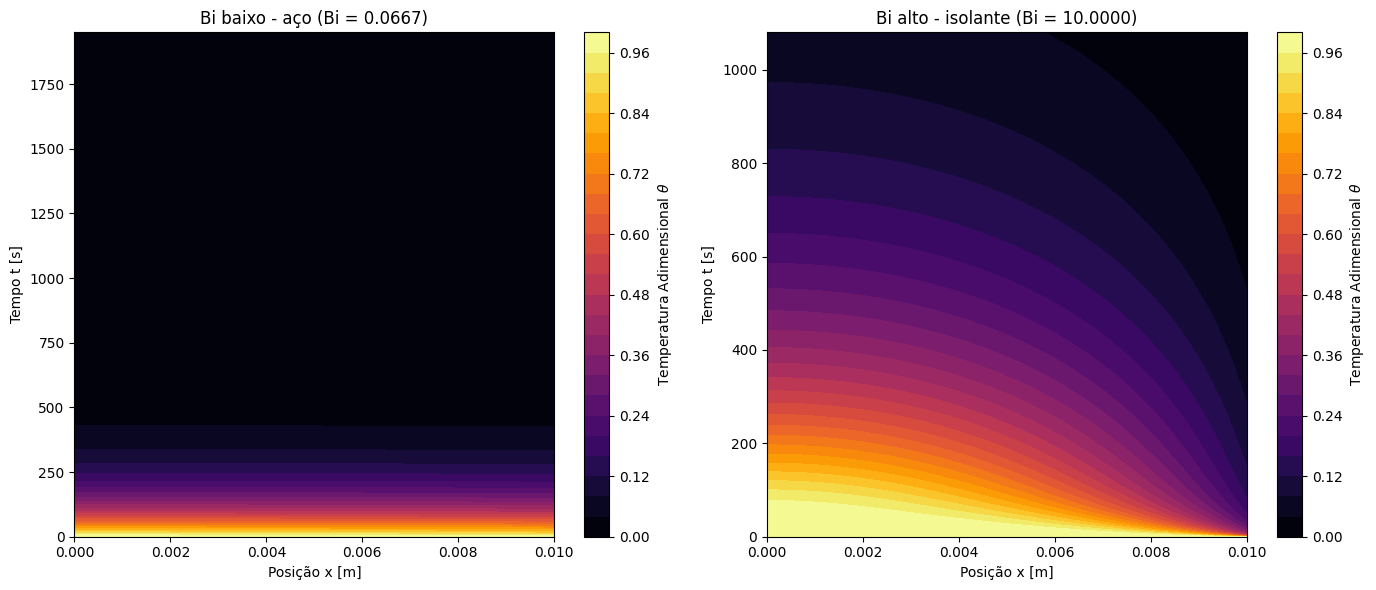

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Criando uma figura com dois subplots lado a lado (um para cada caso)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, res) in zip(axes, resultados.items()):
    x_plot = res["x"]
    t_plot = res["tempo"]
    theta_plot = res["theta"]

    # Criando a malha 2D para a plotagem
    X, Tempo = np.meshgrid(x_plot, t_plot)

    # Plotando o mapa de calor usando contourf
    # Transpomos theta (theta_plot.T) para que a forma bata com (len(t_plot), len(x_plot))
    mapa = ax.contourf(X, Tempo, theta_plot.T, levels=30, cmap='inferno')

    # Formatando o gráfico
    ax.set_title(f"{nome} (Bi = {res['Bi']:.4f})")
    ax.set_xlabel("Posição x [m]")
    ax.set_ylabel("Tempo t [s]")

    # Adicionando a barra de cores individual
    cbar = fig.colorbar(mapa, ax=ax)
    cbar.set_label(r"Temperatura Adimensional $\theta$")

plt.tight_layout()
plt.show()

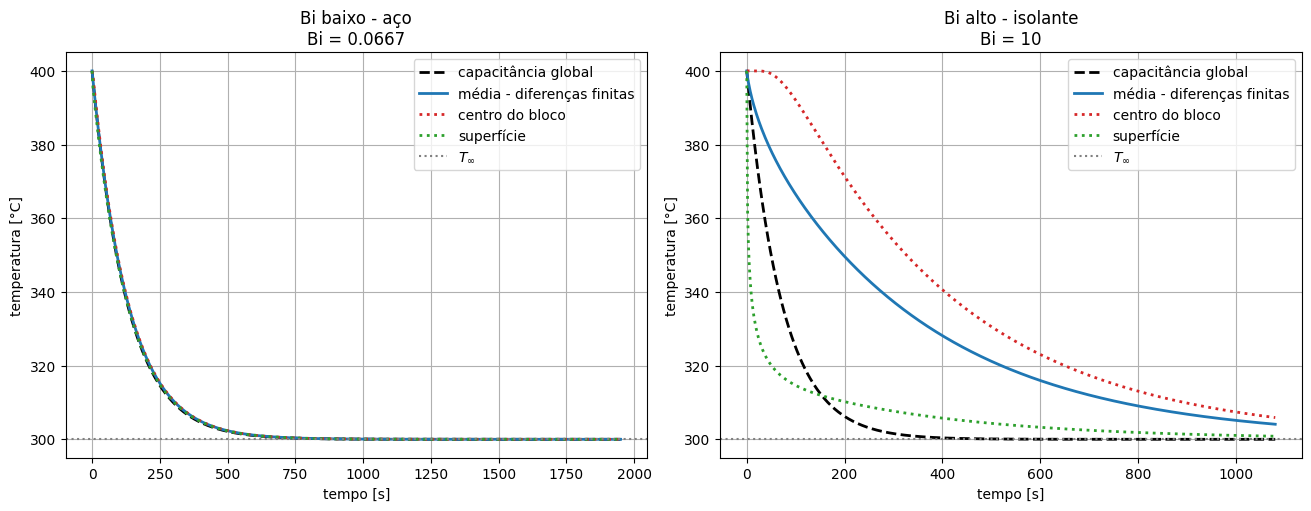

In [9]:
# Comparação utilizando as temperaturas reais

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True,)

for coluna, (nome, resultado) in enumerate(resultados.items()):
    Bi = resultado["Bi"]
    tempo = resultado["tempo"]

    theta_lumped = resultado["theta_lumped"]
    theta_media = resultado["theta_media"]
    theta_centro = resultado["theta"][0, :]
    theta_superficie = resultado["theta"][-1, :]

    # Conversão da temperatura adimensional para temperatura real
    T_lumped = Tinf + (T0 - Tinf) * theta_lumped
    T_media = Tinf + (T0 - Tinf) * theta_media
    T_centro = Tinf + (T0 - Tinf) * theta_centro
    T_superficie = Tinf + (T0 - Tinf) * theta_superficie

    axes[coluna].plot(
        tempo,
        T_lumped,
        "k--",
        linewidth=2,
        label="capacitância global",
    )

    axes[coluna].plot(
        tempo,
        T_media,
        color="tab:blue",
        linewidth=2,
        label="média - diferenças finitas",
    )

    axes[coluna].plot(
        tempo,
        T_centro,
        ":",
        color="tab:red",
        linewidth=2,
        label="centro do bloco",
    )

    axes[coluna].plot(
        tempo,
        T_superficie,
        ":",
        color="tab:green",
        linewidth=2,
        label="superfície",
    )

    axes[coluna].axhline(Tinf, color="gray", linestyle=":", linewidth=1.5,
                         label=r"$T_\infty$",)

    axes[coluna].set_title(f"{nome}\nBi = {Bi:.3g}")

    axes[coluna].set_xlabel("tempo [s]")
    axes[coluna].set_ylabel("temperatura [°C]")
    axes[coluna].set_ylim(Tinf - 5, T0 + 5)
    axes[coluna].grid(True)
    axes[coluna].legend(fontsize=10)

plt.show()

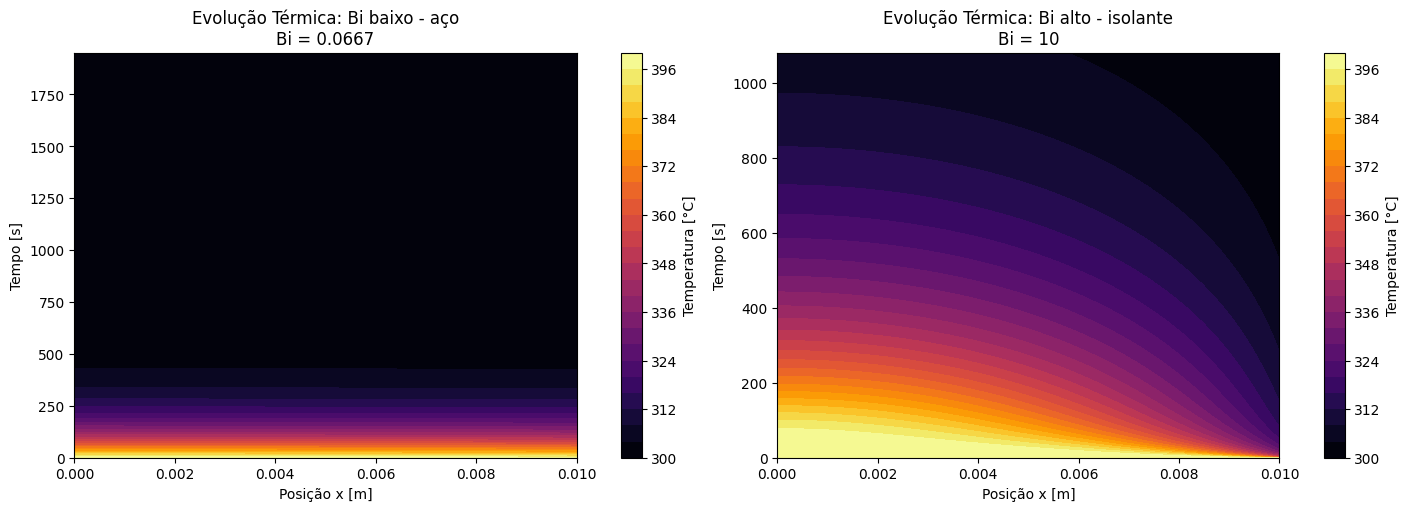

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for coluna, (nome, resultado) in enumerate(resultados.items()):
    x_plot = resultado["x"]
    t_plot = resultado["tempo"]
    theta_plot = resultado["theta"]

    # Conversão da matriz 2D de temperatura adimensional para real
    T_real = Tinf + (T0 - Tinf) * theta_plot

    # Criando a malha 2D para a plotagem
    X, Tempo = np.meshgrid(x_plot, t_plot)

    # Mapa de calor (Transpondo T_real para alinhar X e Tempo)
    mapa = axes[coluna].contourf(
        X,
        Tempo,
        T_real.T,
        levels=30,
        cmap='inferno',
        vmin=Tinf,
        vmax=T0
    )

    axes[coluna].set_title(f"Evolução Térmica: {nome}\nBi = {resultado['Bi']:.3g}")
    axes[coluna].set_xlabel("Posição x [m]")
    axes[coluna].set_ylabel("Tempo [s]")

    # Barra de cores com a unidade em °C
    cbar = fig.colorbar(mapa, ax=axes[coluna])
    cbar.set_label("Temperatura [°C]")

plt.show()

## **Interpretação dos resultados**

No caso com baixo número de Biot, a temperatura no centro, na superfície e a temperatura média permanecem muito próximas. Consequentemente, a curva da capacitância global praticamente coincide com a solução de referência obtida pelas diferenças finitas.

Isso confirma que, para $Bi < 0{,}1$, é razoável representar todo o bloco por uma única temperatura.

No caso com $Bi=10$, aparecem diferenças importantes entre o centro e a superfície. A superfície resfria rapidamente devido à convecção, enquanto o centro permanece mais quente porque o calor demora a se propagar por condução através do material.

Nesse caso, uma única temperatura não representa adequadamente o bloco. A solução da capacitância global prevê um resfriamento muito mais rápido do que o observado na temperatura média obtida pelas diferenças finitas.

Portanto, o número de Biot não é apenas um parâmetro da solução. Ele indica se a hipótese fundamental da capacitância global — temperatura uniforme no sólido — é aceitável.

### **Interpretação do caso com \(Bi=10\)**

Quando \(Bi=10\), a superfície do bloco está diretamente em contato com o fluido e responde rapidamente à convecção. Entretanto, o calor precisa se propagar por condução até o interior do material.

Por isso, a superfície se resfria antes do centro do bloco, gerando um gradiente interno de temperatura:

$$
T_{\text{superfície}}
<
T_{\text{média}}
<
T_{\text{centro}}.
$$

A formulação da capacitância global não calcula especificamente a temperatura da superfície. Ela considera que todo o bloco possui uma única temperatura uniforme.

Assim, qualquer proximidade entre a curva da capacitância global e a curva da superfície ocorre apenas em determinados instantes e não significa que o método esteja representando corretamente essa região.

O resultado correto é que, para \(Bi=10\), a capacitância global deixa de ser adequada, pois não consegue representar simultaneamente as diferentes temperaturas existentes no interior do bloco.

In [10]:
from IPython.display import display, HTML

url_aco = (
    "https://raw.githubusercontent.com/"
    "Paulo-de-Souza/HeatTransferPINN/main/"
    "Aulas_Notebooks/Aula03/gifs_biot/"
    "animacao_aco.gif"
)

url_isolante = (
    "https://raw.githubusercontent.com/"
    "Paulo-de-Souza/HeatTransferPINN/main/"
    "Aulas_Notebooks/Aula03/gifs_biot/"
    "animacao_isolante.gif"
)

display(HTML(f"""
<h3>Bloco de aço — Bi baixo</h3>
<img src="{url_aco}" width="700">

<h3>Bloco isolante — Bi alto</h3>
<img src="{url_isolante}" width="700">
"""))

## **Resumo**

Neste notebook, a condução transiente foi representada por um modelo concentrado:

1. consideramos a temperatura uniforme dentro do sólido;
2. fizemos um balanço entre a energia armazenada e a energia transferida por convecção;
3. obtivemos uma resposta exponencial;
4. usamos a constante de tempo $\tau_t$ para medir a rapidez da resposta;
5. calculamos o número de Biot para verificar se a hipótese é razoável.

O critério $Bi<0{,}1$ é a principal verificação antes de usar a solução da capacitância global. Quando esse critério não é atendido, a temperatura interna pode deixar de ser uniforme e devemos recorrer a uma formulação que considere a variação espacial da temperatura.